In [1]:
!pwd

/home/alan_khang/dev/mirror3d


In [2]:
import sys, os

root = os.getcwd()

sys.path.append(f"{root}/mirror3d/mirror3dnet")

In [3]:
from mirror3d.utils import RefineDepth, read_json, unit_vector
from mirror3d_lib.engine.defaults import Mirror3dTrainer
from mirror3d_lib.config.config import get_cfg
from mirror3d_lib.data.datasets.register_mirror3d_coco import register_mirror3d_coco_instances

from detectron2.checkpoint import DetectionCheckpointer
from detectron2.evaluation import inference_context
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode
from detectron2.data import MetadataCatalog
from detectron2.engine.defaults import DefaultPredictor
from detectron2.modeling import build_model

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import shutil

In [4]:
cfg_file = './mirror3d/mirror3dnet/config/mirror3dnet_config.yml'

cfg = get_cfg() 
cfg.merge_from_file(cfg_file)

# MODEL
cfg.ANCHOR_NORMAL_NYP = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation/kmeans_normal_10.npy'
cfg.MODEL.WEIGHTS = './output/mirror_glass_segm_v11/m3n_full_rawD_resume_2026-03-28-19-07-19/model_final.pth'
cfg.ANCHOR_NORMAL_CLASS_NUM = np.load(cfg.ANCHOR_NORMAL_NYP).shape[0]

# DATASET
cfg.VAL_COCO_JSON = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation/valid_annot.json'
cfg.VAL_IMG_ROOT = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation'

val_name = cfg.VAL_IMG_ROOT.split("/")[-1].split(".")[0]
register_mirror3d_coco_instances(val_name, {}, cfg.VAL_COCO_JSON, cfg.VAL_IMG_ROOT) 

cfg.VAL_NAME = val_name
cfg.DATASETS.TEST = [val_name]
cfg.REFINED_DEPTH = True
cfg.FOCAL_LENGTH = 524 
cfg.DEPTH_SHIFT = 1000 
cfg.EVAL_HEIGHT = 360
cfg.EVAL_WIDTH = 640 
cfg.INPUT.MIN_SIZE_TEST = 360
cfg.INPUT.MAX_SIZE_TEST = 640
cfg.REF_MODE = "rawD_border"

predictor = DefaultPredictor(cfg)
data_loader = Mirror3dTrainer.build_test_loader(cfg, cfg.DATASETS.TEST[0])
depth_refiner = RefineDepth(cfg.FOCAL_LENGTH, cfg.REF_BORDER_WIDTH, cfg.EVAL_WIDTH, cfg.EVAL_HEIGHT)

The checkpoint state_dict contains keys that are not used by the model:
  depth_predictor.conv1.0.{bias, weight}
  depth_predictor.conv1.1.{bias, weight}
  depth_predictor.conv2.0.{bias, weight}
  depth_predictor.conv2.1.{bias, weight}
  depth_predictor.conv3.0.{bias, weight}
  depth_predictor.conv3.1.{bias, weight}
  depth_predictor.conv4.0.{bias, weight}
  depth_predictor.conv4.1.{bias, weight}
  depth_predictor.conv5.0.{bias, weight}
  depth_predictor.conv5.1.{bias, weight}
  depth_predictor.deconv1.1.{bias, weight}
  depth_predictor.deconv1.2.{bias, weight}
  depth_predictor.deconv2.1.{bias, weight}
  depth_predictor.deconv2.2.{bias, weight}
  depth_predictor.deconv3.1.{bias, weight}
  depth_predictor.deconv3.2.{bias, weight}
  depth_predictor.deconv4.1.{bias, weight}
  depth_predictor.deconv4.2.{bias, weight}
  depth_predictor.deconv5.1.{bias, weight}
  depth_predictor.deconv5.2.{bias, weight}
  depth_predictor.depth_pred.{bias, weight}


In [5]:
batch_0 = list(iter(data_loader))[0]

/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))
/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))
/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the l

In [6]:
output_batch_0 = predictor.model(batch_0)

/home/alan_khang/miniconda3/envs/mirror3d/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


scores shape:  torch.Size([50, 2])
proposal_deltas shape:  torch.Size([50, 4])
anchor_normal_score shape:  torch.Size([50, 11])
anchor_residual_pred shape:  torch.Size([50, 33])


In [9]:
score_thresh = 0.7
cnt = 0

output_list = []
with inference_context(model), torch.no_grad():
    for idx, inputs in enumerate(data_loader):
        if cnt == 1:
            break
        if idx < 10:
            continue
        outputs = model(inputs)

        for output in outputs[0]:
            output["instances"] = output["instances"][output["instances"].scores > score_thresh]

        # append some of input information to output_list[]; output_list contrains 
        #  (1) input infomation 
        #  (2) predict depth / predict instance (contains anchor scores, anchor classes, pred boxes.. etc) 
        input_temp = []
        for item in inputs:
            temp = item.copy()
            temp.pop("image")
            if "depth_image" in temp:
                temp.pop("depth_image")
            input_temp.append(temp)
        output_list.append([outputs, input_temp])
        cnt += 1

/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))


In [10]:
anchor_normal = np.load(cfg.ANCHOR_NORMAL_NYP)
imgPath_info = dict()

input_json = read_json(cfg.VAL_COCO_JSON)
for item in input_json["images"]:
    img_path = os.path.join(cfg.VAL_IMG_ROOT, item["mirror_color_image_path"])
    
    imgPath_info[img_path] = item

for i, item in enumerate(output_list):
    one_output, one_input = item
    instances = one_output[0][0]["instances"]
    color_img_path = one_input[0]["mirror_color_image_path"]
    hole_raw_depth_path = os.path.join(cfg.VAL_IMG_ROOT, imgPath_info[color_img_path]["raw_sensorD_path"])

    pred_mask = np.zeros(instances.image_size)
    pred_mask = pred_mask.astype(bool)

    hole_depth_to_ref = cv2.imread(hole_raw_depth_path, cv2.IMREAD_ANYDEPTH)

    if instances.to("cpu").has("pred_masks"):
        for index, one_pred_mask in enumerate(instances.to("cpu").pred_masks):
            
            to_refine_area = one_pred_mask.numpy().astype(bool)
            to_refine_area = np.logical_and(pred_mask==False, to_refine_area)
            if to_refine_area.sum() == 0:
                continue
            pred_mask = np.logical_or(pred_mask , one_pred_mask)
            if instances.to("cpu").pred_anchor_classes[index] >= anchor_normal.shape[0]:
                continue
            pred_normal = anchor_normal[instances.to("cpu").pred_anchor_classes[index]] +  instances.to("cpu").pred_residuals[index].numpy()
            pred_normal = unit_vector(pred_normal)

            if "border" in cfg.REF_MODE :
                hole_depth_to_ref = depth_refiner.refine_depth_by_mirror_border(
                    one_pred_mask.numpy().astype(bool).squeeze(), 
                    pred_normal, 
                    hole_depth_to_ref)
            else:
                raise NotImplementedError("Only border-based refine mode is implemented for now.")
    
    hole_depth_to_ref[hole_depth_to_ref < 0] = 0

In [11]:
for one_output, one_input in output_list:
    instances = one_output[0][0]["instances"]
    if instances.pred_boxes.tensor.shape[0] <= 0:
        print("######## no detection :", img_path)
    img = cv2.imread(img_path)
    v = Visualizer(img[:, :, ::-1], 
        metadata=MetadataCatalog.get("test_10_precise_normal_mirror"), 
        scale=0.5, 
        instance_mode=ColorMode.IMAGE_BW  
    )
    v = v.draw_instance_predictions(instances.to("cpu")) 
    output_img = v.get_image()[:, :, ::-1]

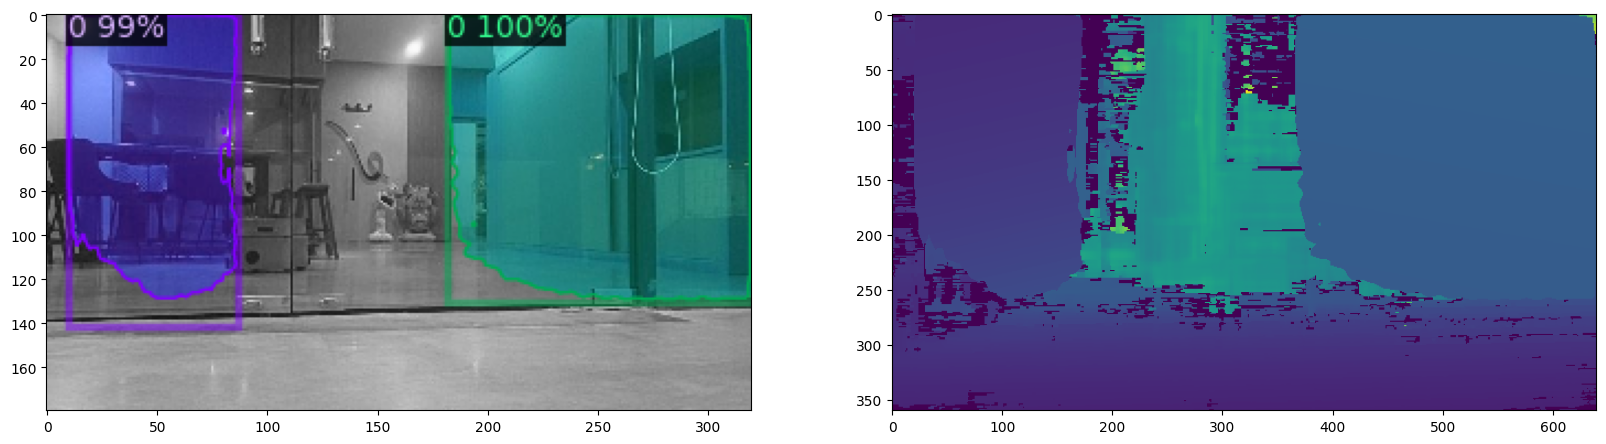

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(output_img)
axes[1].imshow(hole_depth_to_ref, cmap="viridis")
plt.show()

In [11]:
img = cv2.imread('/home/alan_khang/dev/mirror3d/data/Mirror-Glass_Segmentation.v11i.coco-segmentation/train/oak_front_frame_0000049_2026_03_23-20-44-59_jpg.rf.3327b02940f1abdd771dcc45af3d492f.jpg')

#img = predictor.aug.get_transform(img).apply_image(img)

In [12]:
img.shape

(360, 640, 3)

In [13]:
predictor.aug.get_transform(img).apply_image(img).shape

(360, 640, 3)